---
date: "2026-08-26"
date-modified: last-modified
format:
  html:
    toc: true
---


# Position Bias and Unbiased CTR Estimation in Search Systems

In modern search engines, e-commerce platforms, and recommender systems, user click-through rate (CTR) serves as the primary implicit feedback signal for document relevance. However, raw click logs are inherently confounded: items displayed at the top of a Search Engine Results Page (SERP) receive disproportionately more clicks than items displayed further down, regardless of their actual quality.

This case study explores the mathematical foundations of **position bias**, demonstrates how search logs can be formulated as **Binomial processes with non-uniform effective sample sizes**, and derives mathematically rigorous **counterfactual estimators** (Horvitz–Thompson and Hájek/MLE) to obtain unbiased estimates of true document relevance.

---

## 1\. The Core Dilemma: Position Bias in Search Logs

Users do not scan search results uniformly. Instead, eye-tracking studies and behavioral logs demonstrate strong **position bias**—users overwhelmingly examine top-ranked items and rapidly drop off as they scroll down the page.

```
+---------------------------------------------------------------------+
| SERP Slot 1: High Visibility (Propensity p_1 ~ 1.0)                 |
|   -> Document A: Examined -> Clicked (Observed Click = 1)           |
+---------------------------------------------------------------------+
| SERP Slot 2: Moderate Visibility (Propensity p_2 ~ 0.55)            |
|   -> Document B: Examined -> Ignored (Not Relevant, Click = 0)      |
+---------------------------------------------------------------------+
| ...                                                                 |
+---------------------------------------------------------------------+
| SERP Slot 10: Low Visibility (Propensity p_10 ~ 0.05)               |
|   -> Document C: Unexamined (No Click, despite high quality!)       |
+---------------------------------------------------------------------+
```

When evaluating an item or training a Learning-to-Rank (LTR) model, naive CTR conflates two distinct causal events:

1. **Examination Event:** Did the user observe the document slot?
2. **Relevance Event:** Given that the user examined it, did the document satisfy their intent?

If rankers are trained directly on raw clicks without debiasing, a vicious feedback loop occurs: historical top-ranked items accumulate clicks purely due to placement, artificially cementing their high ranks while burying superior documents displayed lower on the page.



## 2\. Probabilistic Foundations: The Examination Hypothesis

To isolate true document quality from layout bias, we formalize the **Examination Hypothesis**.

::: {#def-examination-hypothesis}
## The Examination Hypothesis Model
Let $d$ denote a document presented to a user at SERP rank/slot $k \in \{1, 2, \dots, K\}$. For any impression instance $i$, define the following binary [random variables](random-variables.ipynb):

* **Examination Indicator** $E_i \in \{0, 1\}$: An [indicator random variable](indicator-rv.ipynb) where $E_i = 1$ if the user examines slot $k$, and $E_i = 0$ otherwise.
* **Relevance Indicator** $R_i \in \{0, 1\}$: A latent [Bernoulli](bernoulli-and-binomial-distributions.ipynb) indicator where $R_i = 1$ if document $d$ is perceived as relevant to query $q$, and $R_i = 0$ otherwise.
* **Observed Click Indicator** $C_i \in \{0, 1\}$: The observed outcome where $C_i = 1$ if a click is logged, and $C_i = 0$ otherwise.

Under the Examination Hypothesis, a click occurs if and only if the position is examined **and** the document is relevant:

$$
C_i = 1 \iff E_i = 1 \quad \text{and} \quad R_i = 1
$$
:::

### 2.1\. Causal Independence Assumptions

We formalize the two foundational causal assumptions of the model:

1. **Position Dependence of Examination:** The user's propensity to examine a slot depends exclusively on its visual position $k$, independent of the document content:
   $$
   P(E_i = 1 \mid \text{slot} = k, d) = P(E_i = 1 \mid \text{slot} = k) \equiv p_k \in (0, 1]
   $$
   We define $p_k$ as the **examination propensity** of position $k$.

2. **Content Dependence of Relevance:** Given that a document is examined, its perceived relevance depends solely on document $d$ and query intent $q$, independent of position $k$:
   $$
   P(R_i = 1 \mid d, \text{slot} = k) = P(R_i = 1 \mid d) \equiv r \in [0, 1]
   $$
   We define $r$ as the **true latent relevance** (unbiased CTR) of document $d$.

3. **Conditional Independence:** Given document $d$ and slot $k$, the examination event $E_i = 1$ and the relevance event $R_i = 1$ are conditionally [independent](independence-of-events.ipynb):
   $$
   \begin{aligned}
   P(C_i = 1 \mid d, k) &= P(E_i = 1 \land R_i = 1 \mid d, k) \\
   &= P(E_i = 1 \mid k) \cdot P(R_i = 1 \mid d) \\
   &= p_k \cdot r
   \end{aligned}
   $$

::: {.callout-note}
## Intuition: Factorizing Presentation from Appeal
The product $P(C_i = 1) = p_k \cdot r$ cleanly separates the **presentation mechanism** ($p_k$, governed by UI layout and user browsing psychology) from the **intrinsic document quality** ($r$, the document's true utility). For instance, if an item with true relevance $r = 0.40$ is shown at Slot 1 ($p_1 = 1.0$), its observed CTR is $40\%$. If shown at Slot 10 ($p_{10} = 0.05$), its observed CTR drops to $2\%$. The item's intrinsic quality has not changed—only the observational channel capacity has shrunk.
:::

::: {.callout-warning}
## Common Pitfall: Observational vs. Experimental Independence
In unperturbed production logs, examination and relevance are **unconditionally correlated** because production ranking algorithms systematically place high-relevance items at slot 1. The factorized relation $P(C_i = 1 \mid d, k) = p_k r$ holds *conditionally* on the allocated rank $k$. Treating observational click rates as unconfounded creates a severe instance of [Simpson's Paradox](simpsons-paradox.ipynb).
:::



## 3\. Search Logs as Binomial Experiments with Varying Effective Sizes

Suppose a target document $d$ with true latent relevance $r$ is displayed across $K$ ranking positions over an observational logging window.

For each slot $k \in \{1, 2, \dots, K\}$:

* $N_k \in \mathbb{N}$ is the number of impressions allocated to slot $k$.
* $C_k = \sum_{i=1}^{N_k} C_{i,k}$ is the total count of observed clicks at slot $k$.
* $p_k \in (0, 1]$ is the examination propensity of slot $k$.

::: {#thm-binomial-clicks}
## Binomial Click Distribution per Slot
Under independent impression events, the click count $C_k$ at slot $k$ follows a [Binomial distribution](bernoulli-and-binomial-distributions.ipynb):

$$
C_k \sim \text{Binomial}(N_k, \, p_k r)
$$

with [expected value](expectation.ipynb) and [variance](variance.ipynb):

$$
\begin{aligned}
\mathbb{E}[C_k] &= N_k p_k r \\
\text{Var}(C_k) &= N_k p_k r (1 - p_k r)
\end{aligned}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Binomial Law and Moments
For each impression $i \in \{1, \dots, N_k\}$, the click indicator $C_{i,k}$ is a [Bernoulli random variable](bernoulli-and-binomial-distributions.ipynb) with parameter:

$$
P(C_{i,k} = 1) = p_k \cdot r
$$

Assuming user queries and click choices are mutually [independent](independence-of-rvs.ipynb), $C_k = \sum_{i=1}^{N_k} C_{i,k}$ is the sum of $N_k$ i.i.d. Bernoulli trials. Hence:

$$
C_k \sim \text{Binomial}(N_k, p_k r)
$$

By the linearity of expectation:

$$
\mathbb{E}[C_k] = \sum_{i=1}^{N_k} \mathbb{E}[C_{i,k}] = \sum_{i=1}^{N_k} p_k r = N_k p_k r
$$

By the variance summation rule for independent random variables:

$$
\text{Var}(C_k) = \sum_{i=1}^{N_k} \text{Var}(C_{i,k}) = \sum_{i=1}^{N_k} p_k r (1 - p_k r) = N_k p_k r (1 - p_k r)
$$
$\blacksquare$
:::

### 3.1\. The Effective Examined Sample Size

Notice that the expected total click count across all $K$ slots is:

$$
\mathbb{E}\left[\sum_{k=1}^K C_k\right] = \sum_{k=1}^K N_k p_k r = r \sum_{k=1}^K (N_k p_k)
$$

We define the **effective examined sample size** $N_k^*$ for slot $k$ and the aggregate effective sample size $N^*$ as:

$$
N_k^* \equiv N_k \cdot p_k, \qquad N^* \equiv \sum_{k=1}^K N_k^* = \sum_{k=1}^K N_k p_k
$$

This quantity reveals a crucial statistical insight:

* Showing an item $1,000$ times at Slot 1 ($p_1 = 1.0$) yields $N_1^* = 1,000$ examined opportunities.
* Showing an item $1,000$ times at Slot 10 ($p_{10} = 0.02$) yields only $N_{10}^* = 20$ examined opportunities.

Nominal impressions $N = \sum_{k=1}^K N_k$ are misleading because data collected at lower ranks has drastically lower information density. Any valid estimator of $r$ must account for these unequal sample capacities.



## 4\. Estimator 1: The Horvitz–Thompson Estimator (Standard IPS)

In causal inference and survey sampling, the standard Inverse Propensity Scoring (IPS) strategy is the **Horvitz–Thompson (HT)** estimator. It adjusts for non-uniform examination by re-weighting each observed click inversely by its examination probability.

::: {#def-horvitz-thompson}
## Horvitz–Thompson (HT) Relevance Estimator
Given impression counts $\{N_k\}$, clicks $\{C_k\}$, and propensities $\{p_k\}$ across $K$ slots with total nominal impressions $N = \sum_{k=1}^K N_k$, the **Horvitz–Thompson estimator** $\hat{r}_{\text{HT}}$ is defined as:

$$
\hat{r}_{\text{HT}} = \frac{1}{N} \sum_{k=1}^K \frac{C_k}{p_k}
$$
:::

::: {#prp-ht-properties}
## Statistical Properties of the Horvitz–Thompson Estimator
1. **Strict Finite-Sample Unbiasedness:** For any arbitrary allocation of impressions $\{N_k\}_{k=1}^K$:
   $$
   \mathbb{E}[\hat{r}_{\text{HT}}] = r
   $$
2. **Exact Variance Formulation:**
   $$
   \text{Var}(\hat{r}_{\text{HT}}) = \frac{r}{N^2} \sum_{k=1}^K \frac{N_k (1 - p_k r)}{p_k}
   $$
:::

::: {.callout-tip collapse="true"}
## Proof of Horvitz–Thompson Expectation and Variance
**1. Unbiasedness:**
Taking expectation and substituting $\mathbb{E}[C_k] = N_k p_k r$:

$$
\begin{aligned}
\mathbb{E}[\hat{r}_{\text{HT}}] &= \mathbb{E}\left[ \frac{1}{N} \sum_{k=1}^K \frac{C_k}{p_k} \right] \\
&= \frac{1}{N} \sum_{k=1}^K \frac{\mathbb{E}[C_k]}{p_k} \\
&= \frac{1}{N} \sum_{k=1}^K \frac{N_k p_k r}{p_k} \\
&= \frac{r}{N} \sum_{k=1}^K N_k = \frac{r \cdot N}{N} = r
\end{aligned}
$$

**2. Variance:**
Since click counts across distinct positions are independent random variables:

$$
\begin{aligned}
\text{Var}(\hat{r}_{\text{HT}}) &= \text{Var}\left( \frac{1}{N} \sum_{k=1}^K \frac{C_k}{p_k} \right) \\
&= \frac{1}{N^2} \sum_{k=1}^K \frac{\text{Var}(C_k)}{p_k^2} \\
&= \frac{1}{N^2} \sum_{k=1}^K \frac{N_k p_k r (1 - p_k r)}{p_k^2} \\
&= \frac{r}{N^2} \sum_{k=1}^K \frac{N_k (1 - p_k r)}{p_k}
\end{aligned}
$$
$\blacksquare$
:::

::: {.callout-warning}
## The Practical Pitfall of Horvitz–Thompson: Variance Explosion
Although $\hat{r}_{\text{HT}}$ is mathematically unbiased, it exhibits two severe practical drawbacks in search systems:

1. **Variance Explosion on Low Propensities:** When $p_k$ is small (e.g., $p_{10} = 0.02$), the inverse weight $w_{10} = \frac{1}{0.02} = 50$. A single spurious click at slot 10 is magnified into 50 pseudo-clicks, inducing immense variance.
2. **Unbounded Estimates:** Because the denominator is fixed to nominal $N$, a cluster of lucky clicks at low-propensity ranks can easily cause $\hat{r}_{\text{HT}} > 1.0$ (i.e., a predicted CTR $> 100\%$), violating the probabilistic definition of relevance.
:::



## 5\. Estimator 2: The Hájek (Self-Normalized / Pooled MLE) Estimator

To resolve the variance instability and unboundedness of Horvitz–Thompson, we introduce the **Hájek estimator** (also known as Self-Normalized IPS or Pooled Examined Impressions estimator).

::: {#def-hajek-estimator}
## Hájek (Pooled Examined) Estimator
The **Hájek estimator** $\hat{r}_{\text{H\'{a}jek}}$ normalizes the propensity-weighted clicks by the sum of effective examined impressions rather than nominal impressions:

$$
\hat{r}_{\text{H\'{a}jek}} = \frac{\sum_{k=1}^K \frac{C_k}{p_k}}{\sum_{k=1}^K \frac{N_k \cdot p_k}{p_k}} = \frac{\sum_{k=1}^K C_k}{\sum_{k=1}^K N_k p_k} = \frac{C_{\text{total}}}{N^*}
$$
:::

### 5.1\. Statistical Derivation via Maximum Likelihood Estimation (MLE)

The Hájek estimator is not merely a variance-reduction trick; it is the exact [Maximum Likelihood Estimator](maximum-likelihood-estimation.ipynb) of the joint Binomial data-generating distribution.

::: {#thm-mle-derivation}
## Maximum Likelihood Derivation of Hájek Estimator
Given independent observations $C_k \sim \text{Binomial}(N_k, p_k r)$ across $K$ slots, the Maximum Likelihood Estimator $\hat{r}_{\text{MLE}}$ for sparse click regimes ($p_k r \ll 1$) is:

$$
\hat{r}_{\text{MLE}} = \frac{\sum_{k=1}^K C_k}{\sum_{k=1}^K N_k p_k}
$$
:::

::: {.callout-tip collapse="true"}
## Proof of Maximum Likelihood Derivation
The joint likelihood function for independent observations $(C_1, \dots, C_K)$ is:

$$
L(r) = \prod_{k=1}^K \binom{N_k}{C_k} (p_k r)^{C_k} (1 - p_k r)^{N_k - C_k}
$$

The log-likelihood function $\ell(r) = \ln L(r)$ is:

$$
\ell(r) = \sum_{k=1}^K \left[ \ln \binom{N_k}{C_k} + C_k \ln(p_k r) + (N_k - C_k) \ln(1 - p_k r) \right]
$$

Extracting terms involving $r$:

$$
\ell(r) = \left( \sum_{k=1}^K C_k \right) \ln r + \sum_{k=1}^K (N_k - C_k) \ln(1 - p_k r) + \text{const}
$$

In web search applications, CTR is small ($p_k r \ll 1$). Utilizing the first-order Taylor expansion $\ln(1 - x) = -x - \frac{x^2}{2} - \dots \approx -x$:

$$
\ln(1 - p_k r) \approx -p_k r
$$

Substituting this approximation into the log-likelihood:

$$
\begin{aligned}
\ell(r) &\approx \left( \sum_{k=1}^K C_k \right) \ln r - \sum_{k=1}^K (N_k - C_k) p_k r + \text{const} \\
&\approx \left( \sum_{k=1}^K C_k \right) \ln r - r \sum_{k=1}^K N_k p_k + \text{const} \quad (\text{since } C_k \ll N_k)
\end{aligned}
$$

Differentiating with respect to $r$ and setting the gradient to zero:

$$
\frac{\partial \ell}{\partial r} = \frac{\sum_{k=1}^K C_k}{r} - \sum_{k=1}^K N_k p_k = 0
$$

Solving for $r$ yields the MLE:

$$
\hat{r}_{\text{MLE}} = \frac{\sum_{k=1}^K C_k}{\sum_{k=1}^K N_k p_k} = \frac{C_{\text{total}}}{N^*}
$$
$\blacksquare$
:::

::: {#prp-hajek-properties}
## Statistical Properties of the Hájek Estimator
1. **Asymptotic Consistency & Unbiasedness:** By the [Law of Large Numbers](law-of-large-numbers-and-central-limit-theorem.ipynb), as total impressions $N \to \infty$:
   $$
   \hat{r}_{\text{H\'{a}jek}} \xrightarrow{p} r
   $$
   with a negligible finite-sample ratio bias of order $O(1/N)$.
2. **Minimal Variance:**
   $$
   \text{Var}(\hat{r}_{\text{H\'{a}jek}}) = \frac{\sum_{k=1}^K N_k p_k r (1 - p_k r)}{\left(\sum_{k=1}^K N_k p_k\right)^2} \approx \frac{r}{\sum_{k=1}^K N_k p_k} = \frac{r}{N^*}
   $$
3. **Strict Range Bounding:** Since $0 \le C_k \le N_k$, $\hat{r}_{\text{H\'{a}jek}}$ is naturally regularized and stays strictly within $[0, 1]$.
:::

::: {.callout-note}
## Intuition: Why Hájek Dramatically Outperforms Horvitz–Thompson
Suppose an item receives $1,000$ impressions at Slot 1 ($p_1 = 1.0$) and $1,000$ impressions at Slot 10 ($p_{10} = 0.02$).

* **Horvitz–Thompson:** Weights clicks at Slot 10 by $50$, then divides the total by nominal $N = 2,000$. A single random click at Slot 10 shifts the estimate by $\frac{50}{2000} = +0.025$.
* **Hájek:** Normalizes by effective examined impressions $N^* = 1000(1.0) + 1000(0.02) = 1,020$. A single click at Slot 10 shifts the estimate by $\frac{1}{1020} = +0.00098$.

Hájek avoids blowing up individual clicks by weighting the **denominator** with effective exposures rather than blowing up the numerator!
:::



## 6\. Comprehensive Theoretical Comparison

| Dimension | Naive CTR ($\hat{r}_{\text{naive}}$) | Horvitz–Thompson ($\hat{r}_{\text{HT}}$) | Hájek / Pooled MLE ($\hat{r}_{\text{H\'{a}jek}}$) |
| :--- | :--- | :--- | :--- |
| **Mathematical Formula** | $\frac{\sum C_k}{\sum N_k}$ | $\frac{1}{N} \sum \frac{C_k}{p_k}$ | $\frac{\sum C_k}{\sum N_k p_k}$ |
| **Finite-Sample Bias** | Massive downwards bias ($= r(\bar{p} - 1)$) | **Strictly 0** (Exact Unbiasedness) | Negligible ($O(1/N)$) |
| **Variance Scaling** | $O(1/N)$ | $O\left(\frac{1}{N^2} \sum \frac{N_k}{p_k}\right)$ (Explodes if $p_k \to 0$) | $O\left(\frac{1}{\sum N_k p_k}\right)$ (Minimum achievable) |
| **Range Guarantee** | Strictly in $[0, 1]$ | **Unbounded** (Can exceed $1.0$) | Strictly in $[0, 1]$ |
| **Robustness to Low Propensity** | Poor | Extremely Fragile | Highly Robust |
| **Production Use Case** | Baseline display only | Theoretical proofs | Offline Metrics & LTR Loss Weights |



## 7\. Empirical Simulations & Visualizations

We now implement a complete simulation suite to validate our theoretical derivations:

1. **SERP Environment & Position Bias Simulation:** Illustrating naive CTR inversion.
2. **Monte Carlo Sampling Distributions:** Comparing the empirical variance of HT vs. Hájek.
3. **Bias-Variance-MSE Scaling:** Proving Hájek's MSE superiority across sample sizes $N$.
4. **Propensity Clipping in Learning-to-Rank (LTR):** Tuning the bias-variance tradeoff.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# -- Visual Styling Settings --
plt.rcParams.update({
    'figure.figsize': (13, 5.5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 2,
    'figure.facecolor': '#ffffff',
    'axes.facecolor': '#fbfbfb',
})

# Seed for reproducibility
np.random.seed(42)

# -- SERP Layout & Propensity Parameters --
K_SLOTS = 10
slots = np.arange(1, K_SLOTS + 1)

# Realistic power-law examination curve p_k = (1 / k)^0.75
propensities = (1.0 / slots) ** 0.75

print("SERP Examination Propensities (p_k):")
for k, p in zip(slots, propensities):
    print(f"  Slot {k:2d}: p_{k:<2d} = {p:.4f} ({p*100:5.1f}% examination rate)")


SERP Examination Propensities (p_k):
  Slot  1: p_1  = 1.0000 (100.0% examination rate)
  Slot  2: p_2  = 0.5946 ( 59.5% examination rate)
  Slot  3: p_3  = 0.4387 ( 43.9% examination rate)
  Slot  4: p_4  = 0.3536 ( 35.4% examination rate)
  Slot  5: p_5  = 0.2991 ( 29.9% examination rate)
  Slot  6: p_6  = 0.2608 ( 26.1% examination rate)
  Slot  7: p_7  = 0.2324 ( 23.2% examination rate)
  Slot  8: p_8  = 0.2102 ( 21.0% examination rate)
  Slot  9: p_9  = 0.1925 ( 19.2% examination rate)
  Slot 10: p_10 = 0.1778 ( 17.8% examination rate)



### 7.1\. Simulation 1: The Position Bias Illusion & Inversion

We consider three candidate documents with varying true latent relevance:

* **Document A (High Quality):** $r_A = 0.35$ (35% true relevance)
* **Document B (Medium Quality):** $r_B = 0.20$ (20% true relevance)
* **Document C (Low Quality):** $r_C = 0.08$ (8% true relevance)

We visualize observed CTR across SERP slots and show how poor placement can cause a low-quality item to appear superior to a high-quality item under naive CTR metrics.


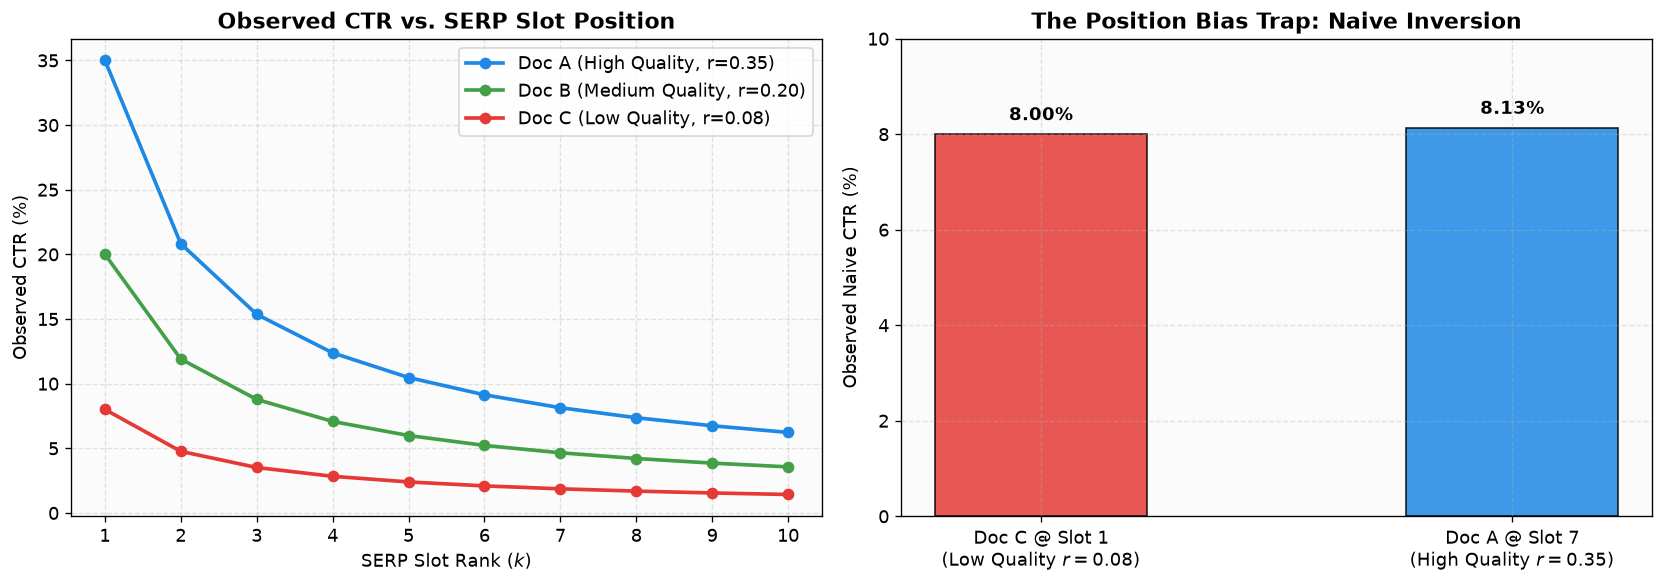

In [2]:
doc_relevance = {'Doc A (High Quality, r=0.35)': 0.35,
                 'Doc B (Medium Quality, r=0.20)': 0.20,
                 'Doc C (Low Quality, r=0.08)': 0.08}
colors = ['#1E88E5', '#43A047', '#E53935']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Observed CTR across SERP Slots
for (name, r), col in zip(doc_relevance.items(), colors):
    observed_ctr = propensities * r
    ax1.plot(slots, observed_ctr * 100, marker='o', label=name, color=col, linewidth=2.2)

ax1.set_title("Observed CTR vs. SERP Slot Position", fontweight='bold')
ax1.set_xlabel("SERP Slot Rank ($k$)")
ax1.set_ylabel("Observed CTR (%)")
ax1.set_xticks(slots)
ax1.legend(frameon=True, facecolor='white')

# Plot 2: Demonstrating Position Confounding (Ranking Inversion)
# Scenario: Doc C shown at Slot 1 vs Doc A shown at Slot 7
c_at_slot1_ctr = propensities[0] * doc_relevance['Doc C (Low Quality, r=0.08)'] * 100
a_at_slot7_ctr = propensities[6] * doc_relevance['Doc A (High Quality, r=0.35)'] * 100

bars = ax2.bar(['Doc C @ Slot 1\n(Low Quality $r=0.08$)', 'Doc A @ Slot 7\n(High Quality $r=0.35$)'],
               [c_at_slot1_ctr, a_at_slot7_ctr],
               color=['#E53935', '#1E88E5'], width=0.45, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, yval + 0.2, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')

ax2.set_title("The Position Bias Trap: Naive Inversion", fontweight='bold')
ax2.set_ylabel("Observed Naive CTR (%)")
ax2.set_ylim(0, 10)

plt.tight_layout()
plt.show()



### 7.2\. Simulation 2: Monte Carlo Sampling Distribution Analysis

To directly compare the variance and stability of the estimators, we simulate $M = 10,000$ independent trials of search logs for an item with true relevance $r = 0.25$.

Impressions are non-uniformly distributed across 10 slots (reflecting a typical search traffic allocation where top slots receive more traffic). We compute the empirical sampling distributions for:

1. **Naive Estimator:** $\hat{r}_{\text{naive}} = \frac{\sum C_k}{\sum N_k}$
2. **Horvitz–Thompson Estimator:** $\hat{r}_{\text{HT}} = \frac{1}{N} \sum \frac{C_k}{p_k}$
3. **Hájek Estimator:** $\hat{r}_{\text{H\'{a}jek}} = \frac{\sum C_k}{\sum N_k p_k}$


<>:38: SyntaxWarning: invalid escape sequence '\h'
<>:38: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_23376/668606828.py:38: SyntaxWarning: invalid escape sequence '\h'
  ax.set_xlabel("Estimated Relevance ($\hat{r}$)")


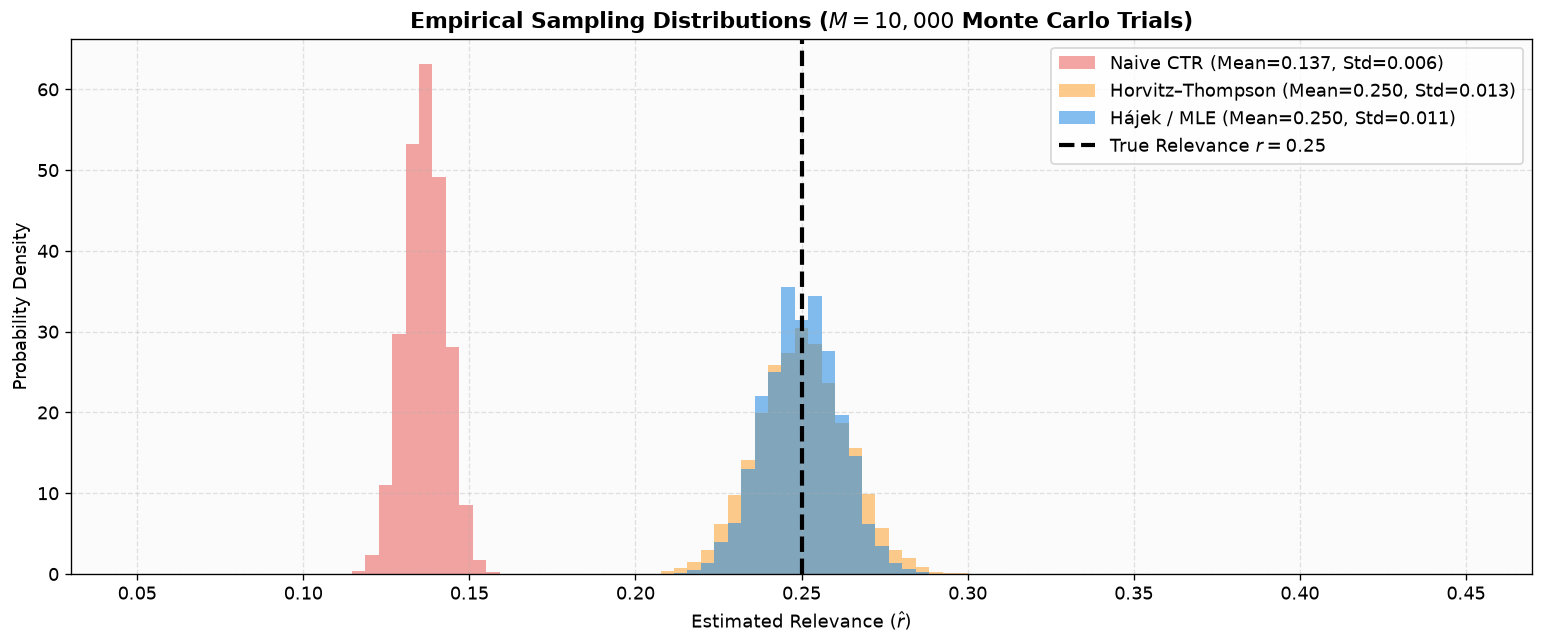

Summary Statistics:
  True Relevance : 0.2500
  Naive CTR      : Mean = 0.1366 (Bias = -0.1134), Std = 0.0061
  Horvitz-Thompson: Mean = 0.2501 (Bias = +0.0001), Std = 0.0134
  Hájek (MLE)    : Mean = 0.2501 (Bias = +0.0001), Std = 0.0112


In [3]:
def run_monte_carlo(true_r=0.25, N_total=5000, n_trials=10000):
    # Non-uniform slot impression distribution (more traffic at top slots)
    slot_weights = np.array([0.25, 0.20, 0.15, 0.12, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02])
    N_k = np.round(N_total * slot_weights).astype(int)
    N_actual = np.sum(N_k)
    
    # True click probabilities per slot
    prob_click = propensities * true_r
    
    # Generate Binomial click counts for all trials simultaneously: shape (n_trials, K)
    clicks = np.random.binomial(n=N_k, p=prob_click, size=(n_trials, K_SLOTS))
    
    # Estimator 1: Naive CTR
    r_naive = np.sum(clicks, axis=1) / N_actual
    
    # Estimator 2: Horvitz-Thompson
    r_ht = np.sum(clicks / propensities, axis=1) / N_actual
    
    # Estimator 3: Hajek / MLE
    effective_N = np.sum(N_k * propensities)
    r_hajek = np.sum(clicks, axis=1) / effective_N
    
    return r_naive, r_ht, r_hajek, true_r

r_naive, r_ht, r_hajek, true_r = run_monte_carlo(true_r=0.25, N_total=3000, n_trials=10000)

# -- Visualization of Sampling Distributions --
fig, ax = plt.subplots(figsize=(13, 5.5))

bins = np.linspace(0.05, 0.45, 100)
ax.hist(r_naive, bins=bins, density=True, alpha=0.45, color='#E53935', label=f'Naive CTR (Mean={r_naive.mean():.3f}, Std={r_naive.std():.3f})')
ax.hist(r_ht, bins=bins, density=True, alpha=0.45, color='#FB8C00', label=f'Horvitz–Thompson (Mean={r_ht.mean():.3f}, Std={r_ht.std():.3f})')
ax.hist(r_hajek, bins=bins, density=True, alpha=0.55, color='#1E88E5', label=f'Hájek / MLE (Mean={r_hajek.mean():.3f}, Std={r_hajek.std():.3f})')

ax.axvline(true_r, color='black', linestyle='--', linewidth=2.5, label=f'True Relevance $r = {true_r:.2f}$')

ax.set_title("Empirical Sampling Distributions ($M=10,000$ Monte Carlo Trials)", fontweight='bold')
ax.set_xlabel("Estimated Relevance ($\hat{r}$)")
ax.set_ylabel("Probability Density")
ax.legend(frameon=True, facecolor='white', loc='upper right')
plt.tight_layout()
plt.show()

print(f"Summary Statistics:")
print(f"  True Relevance : {true_r:.4f}")
print(f"  Naive CTR      : Mean = {r_naive.mean():.4f} (Bias = {r_naive.mean() - true_r:+.4f}), Std = {r_naive.std():.4f}")
print(f"  Horvitz-Thompson: Mean = {r_ht.mean():.4f} (Bias = {r_ht.mean() - true_r:+.4f}), Std = {r_ht.std():.4f}")
print(f"  Hájek (MLE)    : Mean = {r_hajek.mean():.4f} (Bias = {r_hajek.mean() - true_r:+.4f}), Std = {r_hajek.std():.4f}")



### 7.3\. Simulation 3: Bias, Variance, and MSE Scaling Analysis

We systematically evaluate the **Mean Squared Error (MSE)** decomposition across sample sizes $N \in [100, 20000]$:

$$
\text{MSE}(\hat{r}) = \mathbb{E}[(\hat{r} - r)^2] = \text{Bias}(\hat{r})^2 + \text{Var}(\hat{r})
$$

We plot Bias, Variance, and total MSE on log scales to confirm the theoretical convergence rates.


<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_23376/3694780549.py:52: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Absolute Bias: $|\mathbb{E}[\hat{r}] - r|$", fontweight='bold')
/tmp/ipykernel_23376/3694780549.py:63: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title("Variance: $\text{Var}(\hat{r})$", fontweight='bold')


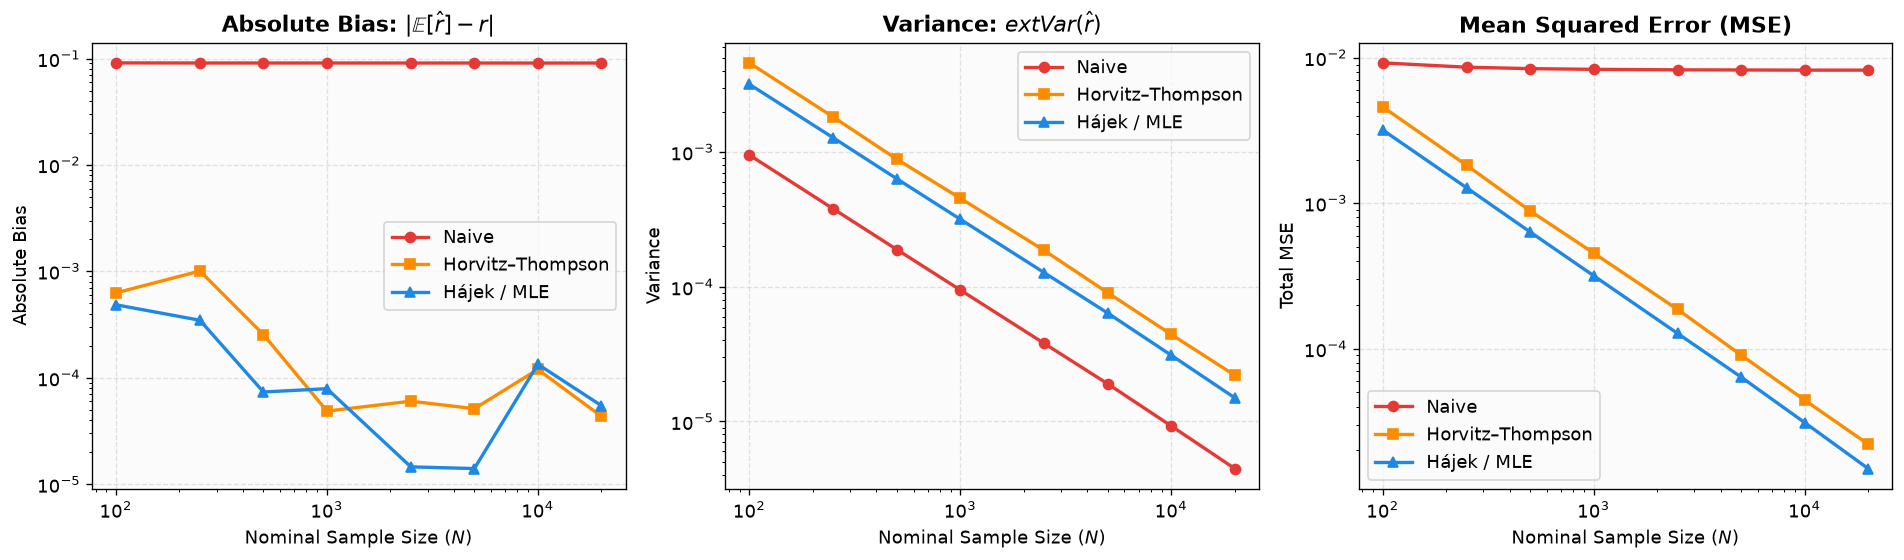

In [4]:
sample_sizes = np.array([100, 250, 500, 1000, 2500, 5000, 10000, 20000])
true_r = 0.20
n_trials = 5000

metrics = {'HT': {'bias': [], 'var': [], 'mse': []},
           'Hajek': {'bias': [], 'var': [], 'mse': []},
           'Naive': {'bias': [], 'var': [], 'mse': []}}

slot_weights = np.array([0.25, 0.20, 0.15, 0.12, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02])

for N in sample_sizes:
    N_k = np.round(N * slot_weights).astype(int)
    N_actual = np.sum(N_k)
    prob_click = propensities * true_r
    
    clicks = np.random.binomial(n=N_k, p=prob_click, size=(n_trials, K_SLOTS))
    
    # Naive
    r_nv = np.sum(clicks, axis=1) / N_actual
    bias_nv = np.mean(r_nv) - true_r
    var_nv = np.var(r_nv)
    metrics['Naive']['bias'].append(bias_nv)
    metrics['Naive']['var'].append(var_nv)
    metrics['Naive']['mse'].append(bias_nv**2 + var_nv)
    
    # HT
    r_h = np.sum(clicks / propensities, axis=1) / N_actual
    bias_h = np.mean(r_h) - true_r
    var_h = np.var(r_h)
    metrics['HT']['bias'].append(bias_h)
    metrics['HT']['var'].append(var_h)
    metrics['HT']['mse'].append(bias_h**2 + var_h)
    
    # Hajek
    eff_N = np.sum(N_k * propensities)
    r_hj = np.sum(clicks, axis=1) / eff_N
    bias_hj = np.mean(r_hj) - true_r
    var_hj = np.var(r_hj)
    metrics['Hajek']['bias'].append(bias_hj)
    metrics['Hajek']['var'].append(var_hj)
    metrics['Hajek']['mse'].append(bias_hj**2 + var_hj)

# -- Plotting Bias, Variance, MSE --
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4.8))

# 1. Absolute Bias
ax1.plot(sample_sizes, np.abs(metrics['Naive']['bias']), marker='o', color='#E53935', label='Naive')
ax1.plot(sample_sizes, np.abs(metrics['HT']['bias']), marker='s', color='#FB8C00', label='Horvitz–Thompson')
ax1.plot(sample_sizes, np.abs(metrics['Hajek']['bias']), marker='^', color='#1E88E5', label='Hájek / MLE')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title("Absolute Bias: $|\mathbb{E}[\hat{r}] - r|$", fontweight='bold')
ax1.set_xlabel("Nominal Sample Size ($N$)")
ax1.set_ylabel("Absolute Bias")
ax1.legend()

# 2. Variance
ax2.plot(sample_sizes, metrics['Naive']['var'], marker='o', color='#E53935', label='Naive')
ax2.plot(sample_sizes, metrics['HT']['var'], marker='s', color='#FB8C00', label='Horvitz–Thompson')
ax2.plot(sample_sizes, metrics['Hajek']['var'], marker='^', color='#1E88E5', label='Hájek / MLE')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title("Variance: $\text{Var}(\hat{r})$", fontweight='bold')
ax2.set_xlabel("Nominal Sample Size ($N$)")
ax2.set_ylabel("Variance")
ax2.legend()

# 3. Total MSE
ax3.plot(sample_sizes, metrics['Naive']['mse'], marker='o', color='#E53935', label='Naive')
ax3.plot(sample_sizes, metrics['HT']['mse'], marker='s', color='#FB8C00', label='Horvitz–Thompson')
ax3.plot(sample_sizes, metrics['Hajek']['mse'], marker='^', color='#1E88E5', label='Hájek / MLE')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_title("Mean Squared Error (MSE)", fontweight='bold')
ax3.set_xlabel("Nominal Sample Size ($N$)")
ax3.set_ylabel("Total MSE")
ax3.legend()

plt.tight_layout()
plt.show()



### 7.4\. Simulation 4: Propensity Clipping in Learning-to-Rank (LTR)

When training Learning-to-Rank algorithms (e.g., LambdaMART or neural rankers) via unbiased counterfactual losses, individual click instances are re-weighted by inverse propensity weights $w_k = \frac{1}{p_k}$.

To prevent gradient explosion on deep slots with very low $p_k$, practitioners apply **propensity clipping** with a hyperparameter threshold $M > 1$:

$$
w_k^{\text{clip}} = \min\left( \frac{1}{p_k}, \, M \right)
$$

This introduces a controlled amount of bias in exchange for a massive reduction in gradient variance. We evaluate the resulting **Bias-Variance-MSE tradeoff curve** across varying clipping thresholds $M$.


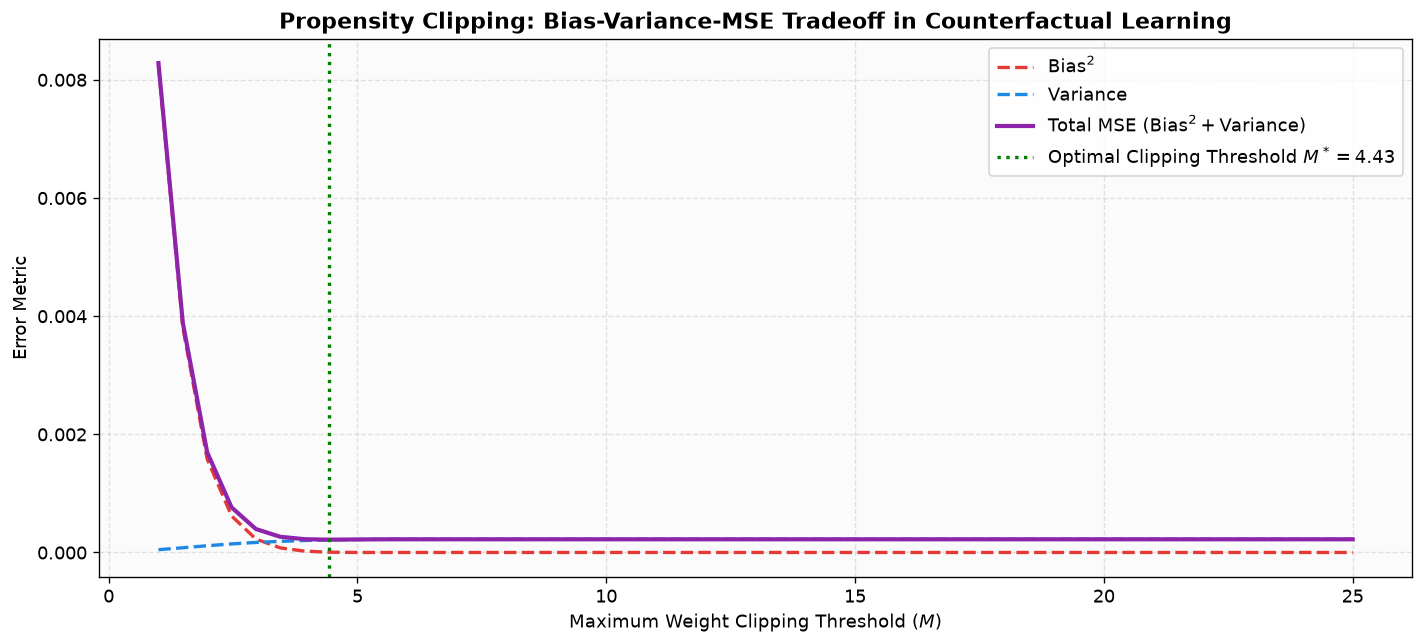

Optimal Clipping Threshold: M* = 4.43
  At M*=4.43 : MSE = 0.000217 (Variance = 0.000212, Bias^2 = 0.000005)
  Unclipped (M=25.0): MSE = 0.000223 (Variance = 0.000223, Bias^2 = 0.000000)


In [5]:
clipping_thresholds = np.linspace(1.0, 25.0, 50)
true_r = 0.20
N_total = 2000
n_trials = 10000

slot_weights = np.array([0.25, 0.20, 0.15, 0.12, 0.08, 0.06, 0.05, 0.04, 0.03, 0.02])
N_k = np.round(N_total * slot_weights).astype(int)
N_actual = np.sum(N_k)
prob_click = propensities * true_r
clicks = np.random.binomial(n=N_k, p=prob_click, size=(n_trials, K_SLOTS))

clip_biases = []
clip_vars = []
clip_mses = []

for M in clipping_thresholds:
    clipped_weights = np.minimum(1.0 / propensities, M)
    # Weighted click estimate
    r_clipped = np.sum(clicks * clipped_weights, axis=1) / N_actual
    
    b = np.mean(r_clipped) - true_r
    v = np.var(r_clipped)
    clip_biases.append(b ** 2)
    clip_vars.append(v)
    clip_mses.append(b ** 2 + v)

opt_idx = np.argmin(clip_mses)
opt_M = clipping_thresholds[opt_idx]

# Plotting the Tradeoff Curve
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(clipping_thresholds, clip_biases, label='$\\text{Bias}^2$', color='#E53935', linestyle='--')
ax.plot(clipping_thresholds, clip_vars, label='$\\text{Variance}$', color='#1E88E5', linestyle='--')
ax.plot(clipping_thresholds, clip_mses, label='Total MSE ($\\text{Bias}^2 + \\text{Variance}$)', color='#8E24AA', linewidth=2.5)

ax.axvline(opt_M, color='green', linestyle=':', linewidth=2, label=f'Optimal Clipping Threshold $M^* = {opt_M:.2f}$')

ax.set_title("Propensity Clipping: Bias-Variance-MSE Tradeoff in Counterfactual Learning", fontweight='bold')
ax.set_xlabel("Maximum Weight Clipping Threshold ($M$)")
ax.set_ylabel("Error Metric")
ax.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.show()

print(f"Optimal Clipping Threshold: M* = {opt_M:.2f}")
print(f"  At M*={opt_M:.2f} : MSE = {clip_mses[opt_idx]:.6f} (Variance = {clip_vars[opt_idx]:.6f}, Bias^2 = {clip_biases[opt_idx]:.6f})")
print(f"  Unclipped (M=25.0): MSE = {clip_mses[-1]:.6f} (Variance = {clip_vars[-1]:.6f}, Bias^2 = {clip_biases[-1]:.6f})")



## 8\. Practical Implementation Guidelines for Production Systems

When integrating position debiasing into production search and ranking engines, adhere to the following architecture principles:

### 8.1\. Propensity Estimation Techniques

Accurate propensities $p_k$ are the prerequisite for unbiased inference. Never use raw average CTR per slot as propensities, as raw slot CTR is confounded by document quality.

1. **Intervention Experiments (RandTopN / Interleaving):** Uniformly randomize top-$N$ candidate items on a small fraction ($1\%$) of user traffic. In randomized traffic, document quality is conditionally independent of position, enabling direct estimation:
   $$
   \hat{p}_k = \frac{\text{Clicks at slot } k \text{ in randomized bucket}}{\text{Clicks at slot } 1 \text{ in randomized bucket}}
   $$
2. **Expectation-Maximization (EM) over Unclicked Logs:** Jointly estimate latent document relevance vectors $\mathbf{r}$ and propensity parameters $\mathbf{p}$ via the EM algorithm on regular search logs without intrusive online experimentation.

### 8.2\. Decision Framework for Pipeline Components

* **For Offline Item Quality Evaluation & Dashboards:** Always use the **Hájek Estimator** ($\hat{r}_{\text{H\'{a}jek}} = \frac{\sum C_k}{\sum N_k p_k}$). It guarantees bounded, low-variance scores.
* **For Gradient-Based Learning-to-Rank Models:** Use inverse propensity weighting with **Propensity Clipping** ($w_i = \min(1/p_k, M)$) on the pairwise or listwise loss function to safeguard training stability.

---

> **References & Acknowledgments:**
> Formulations and examination models adapted from *An Experimental Comparison of Click Position-Bias Models* by Craswell et al. (2008), *Unbiased Learning-to-Rank with Biased Feedback* by Joachims et al. (2017), and foundational causal survey sampling theory for the Horvitz–Thompson and Hájek estimators.
